
TABLA DE LOGARITMOS (BRIGGS)
----------------------------------------------------------------------
x    Aprox          Real           Error Relativo
----------------------------------------------------------------------
1    0.00000000     0.00000000     0.00000000
2    0.30431188     0.30103000     0.01090219
3    0.48540921     0.47712125     0.01737074
4    0.60862376     0.60205999     0.01090219
5    0.69568812     0.69897000     0.00469532
6    0.78972109     0.77815125     0.01486836
7    0.87132676     0.84509804     0.03103630
8    0.91293564     0.90308999     0.01090219
9    0.97081841     0.95424251     0.01737074
10   1.00000000     1.00000000     0.00000000


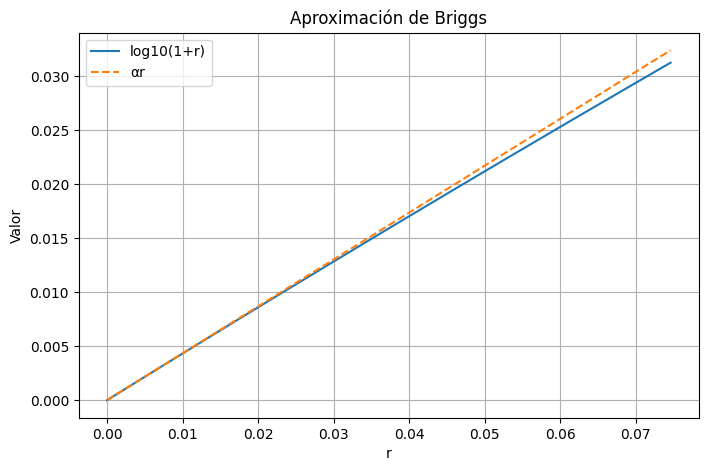


Máximo error absoluto = 0.0011517681467333347

Comparación para log10(6)
----------------------------------------
Valor real           : 0.7781512503836436
Método directo       : 0.800352614809865
Error directo        : 0.022201364426221337
Usando log(2)+log(3) : 0.7897210858928747
Error propiedad      : 0.011569835509231075

La mejor aproximación es log10(2)+log10(3)


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Constante de Briggs
alpha = 1 / math.log(10)


def briggs_log(x, n=5):
    y = float(x)

    # 5 raíces cuadradas
    for _ in range(n):
        y = round(math.sqrt(y), 6)

    r = y - 1

    # Aproximación lineal
    return (2**n) * alpha * r


# Cálculo de log

logs = {}

logs[1] = 0.0
logs[2] = briggs_log(2)
logs[3] = briggs_log(3)

# propiedades de logaritmos
logs[4] = 2 * logs[2]
logs[5] = 1 - logs[2]
logs[6] = logs[2] + logs[3]
logs[7] = briggs_log(7)
logs[8] = 3 * logs[2]
logs[9] = 2 * logs[3]
logs[10] = 1.0


print("\nTABLA DE LOGARITMOS (BRIGGS)")
print("-" * 70)
print(f"{'x':<5}{'Aprox':<15}{'Real':<15}{'Error Relativo'}")
print("-" * 70)

for x in range(1, 11):
    real = math.log10(x)
    aprox = logs[x]

    if real == 0:
        error_rel = 0
    else:
        error_rel = abs((aprox - real) / real)

    print(f"{x:<5}{aprox:<15.8f}{real:<15.8f}{error_rel:.8f}")


# Gráfica
r_max = pow(10, 1/32) - 1

r = np.linspace(0, r_max, 500)

real = np.log10(1 + r)
aprox = alpha * r

error_abs = np.max(np.abs(real - aprox))

plt.figure(figsize=(8,5))
plt.plot(r, real, label='log10(1+r)')
plt.plot(r, aprox, '--', label='αr')
plt.xlabel('r')
plt.ylabel('Valor')
plt.title('Aproximación de Briggs')
plt.grid(True)
plt.legend()
plt.show()

print("\nMáximo error absoluto =", error_abs)


#  para log10(6)

directo = briggs_log(6)
propiedad = logs[2] + logs[3]
real6 = math.log10(6)

err_directo = abs(directo - real6)
err_propiedad = abs(propiedad - real6)

print("\nComparación para log10(6)")
print("-" * 40)
print("Valor real           :", real6)
print("Método directo       :", directo)
print("Error directo        :", err_directo)
print("Usando log(2)+log(3) :", propiedad)
print("Error propiedad      :", err_propiedad)

if err_propiedad < err_directo:
    print("\nLa mejor aproximación es log10(2)+log10(3)")
else:
    print("\nLa mejor aproximación es la obtenida directamente")